## Packages and env setup

In [1]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
# pip install transformers==4.37.1

In [3]:
# pip install datasets

In [4]:
# ps aux | grep python

In [5]:
# ps aux | grep python

In [6]:
# nvidia-smi

## Constants

In [ ]:
model_name = 'EleutherAI/gpt-neo-1.3B'
dataset_name = 'tatsu-lab/alpaca'

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer

## Tokenizer and Model

In [9]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Workaround with Tokens

In [10]:
text = 'hello, i\'m wimukthi'
tokens = tokenizer(text)
print(tokens)

{'input_ids': [31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [11]:
# print(tokenizer.decode(tokens))

In [12]:
texts = ['hello, i\'m wimukthi', 'i love coding', 'living in Australia']
tokens_obj = tokenizer(texts)
print(tokens_obj)

{'input_ids': [[31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], [72, 1842, 19617], [19950, 287, 4505]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1], [1, 1, 1]]}


In [13]:
for t in tokens_obj['input_ids']:
  print(tokenizer.decode(t))

hello, i'm wimukthi
i love coding
living in Australia


## Load Dataset

In [14]:
from datasets import load_dataset

In [15]:
dataset = load_dataset(dataset_name)
split = dataset["train"].shuffle(seed=42).select(range(10000)).train_test_split(test_size=0.2)

train_dataset = split["train"]
val_dataset = split["test"]

In [16]:
split

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 2000
    })
})

In [17]:
train_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 8000
})

In [18]:
val_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 2000
})

## Preprocess

In [19]:
def preprocess(example):
    if example['input'].strip() != "":
        prompt = f"Instruction: {example['instruction']}\nInput: {example['input']}\nAnswer:"
    else:
        prompt = f"Instruction: {example['instruction']}\nAnswer:"
    labels = example['output']
    return {"prompt": prompt, "labels": labels}

In [20]:
# ds_train, ds_val = ds['train'], ds['validation']

In [21]:
ds_train = train_dataset.map(preprocess)
ds_val = val_dataset.map(preprocess)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [22]:
ds_train[:10]

{'instruction': ['List five benefits of using renewable energy sources.',
  'Write a compile time error regarding the given code.',
  'Classify the following text as either describing a computer vision task or a natural language processing task.',
  'Say something encouraging to someone who failed an exam.',
  'Explain what a reverse auction is',
  'Identify the figure of speech used in the phrase "An apple a day keeps the doctor away."',
  'Create a fill in the blank question from the given sentence.',
  'Describe how the leaders of a country can develop economic security for the citizens of the nation.',
  'Given two pressure values in Pascals, compute the difference.',
  'Generate a three step procedure for cleaning a computer keyboard.'],
 'input': ['',
  "def someFunction():\n    print('Hello')",
  'The computer is capable of automatically detecting the faces in an image.',
  '',
  '',
  '',
  'Tom is a popular student at the school.',
  '',
  '400Pa, 800Pa',
  ''],
 'output': ['F

## Tokenization

In [23]:
def tokenize(batch):
    # Ensure inputs are lists of strings
    prompts = batch["prompt"]
    labels = batch["labels"]

    encodings = tokenizer(
        prompts,
        truncation=True,
        padding="max_length",
        max_length=512
    )
    
    label_encodings = tokenizer(
        labels,
        truncation=True,
        padding="max_length",
        max_length=128
    )
    
    # Assign label input_ids
    encodings["labels"] = label_encodings["input_ids"]
    
    return encodings

In [24]:
ds_train.column_names

['instruction', 'input', 'output', 'text', 'prompt', 'labels']

In [25]:
# tokenized_ds = ds_train.map(tokenize, batched=True, batch_size=512, remove_columns=['instruction', 'input', 'output', 'text', 'prompt', 'labels'])


train_dataset_tokenized = ds_train.map(
    tokenize,
    batched=True,
    batch_size=64,  # smaller batch size for map to avoid memory issues
    remove_columns=ds_train.column_names
)

val_dataset_tokenized = ds_val.map(
    tokenize,
    batched=True,
    batch_size=64,
    remove_columns=ds_val.column_names
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [26]:
# tokenized_ds

In [27]:
train_dataset_tokenized.set_format(type='torch')
val_dataset_tokenized.set_format(type='torch')

In [28]:
# map_kwargs = {
#     'batched': True,
#     'batch_size': 512,
#     'remove_columns': ['idx', 'sentence', 'label']
# }
# tokenized_dataset_train = ds_train.map(tokenize, **map_kwargs)
# tokenized_dataset_val = ds_val.map(tokenize, **map_kwargs)

In [29]:
# tokenized_dataset_train[:4]

In [30]:
# for i, j in enumerate(tokenized_dataset_train[:4]['input_ids']):
#   print(f'{i+1}: {tokenizer.decode(j)}')

In [31]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [32]:
# tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
# tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [33]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [34]:
# tokenized_dataset_train.set_format(type='torch')
# tokenized_dataset_val.set_format(type='torch')

In [35]:
# tokenized_dataset_train[:5]

In [36]:
# print(tokenizer.pad_token)

In [37]:
print(train_dataset_tokenized[0])

{'labels': tensor([20029,  4034,   286,  1262, 15713,  2568,  4237,  2291,    25,   220,
          198,    16,    13,  1119,  4646, 20203,   319,  1729,    12,   918,
          413,   540,  4237,   286,  2568,    11,  4145, 23934,  3288,  4133,
           13,   220,   198,    17,    13,  1119,   389,  1575,    12, 16803,
          290,  1342,  5789,   287,   262,   890,    12,  4354,    13,   220,
          198,    18,    13,  1119,   466,   407,  4439,   597,  3278, 15129,
         8971,    11,  1642,   606,   517, 34132,  8030,    13,   220,   198,
           19,    13,  1119,   460,  1037,   284,  7719,  2568,  2324,   416,
        15070,  4035,  2568,  4237,    13,   220,   198,    20,    13,  1119,
          460,  2897,   517,  9314,  2568,  5127,   621,  1729,    12,   918,
          413,   540,  4237,    13, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 502

## Collator

In [38]:
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

In [39]:
tokenizer.pad_token = tokenizer.eos_token

In [40]:
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

dataloader_param = {
    'batch_size': 8,
    'collate_fn': data_collator,
    'shuffle': True
}
train_dataloader = DataLoader(train_dataset_tokenized, **dataloader_param)
val_dataloader = DataLoader(val_dataset_tokenized, **dataloader_param)

In [41]:
len(train_dataloader)

1000

In [42]:
# batch = next(iter(train_dataloader))
# print(batch.keys())

In [43]:
# batch['input_ids'].shape

In [44]:
# batch['input_ids'][0]

In [45]:
# batch['labels'][0]

In [46]:
# batch['attention_mask'][0]

## Optimizer

In [47]:
import torch

In [48]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [49]:
# def validate(epoch):
#   model.eval()
#   total_loss = 0.0
#   for i, batch in enumerate(val_dataloader):
#     batch = {k: v.to(device) for k, v in batch.items()}
#     optimizer.zero_grad()
#     with torch.cuda.amp.autocast():
#       outputs = model(**batch)
#       loss = outputs.loss
#       total_loss += loss.item()
#   print(f'validation loss at epoch {epoch}: {total_loss/len(val_dataloader)}')

In [50]:
len(train_dataloader)

1000

## Training

In [51]:
num_epochs = 3
train_losses = []
val_losses = []


model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for i, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        print("loss:", loss.item())
        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} completed. Avg Train Loss: {avg_train_loss:.4f}")

    # --------------------------
    # Validation
    # --------------------------
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss = outputs.loss
            total_val_loss += val_loss.item()
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1} completed. Avg Validation Loss: {avg_val_loss:.4f}")

loss: 4.890368938446045
Epoch 1, Step 0, Train Loss: 4.8904
loss: 4.329560279846191
loss: 4.081672668457031
loss: 4.2700042724609375
loss: 3.919058322906494
loss: 3.7244362831115723
loss: 3.580739736557007
loss: 3.538205862045288
loss: 3.0765130519866943
loss: 3.4029390811920166
loss: 3.2099435329437256
loss: 3.285007953643799
loss: 3.300320625305176
loss: 3.09430193901062
loss: 3.103193521499634
loss: 3.215423822402954
loss: 2.7293200492858887
loss: 2.9932315349578857
loss: 3.0766098499298096
loss: 3.263091564178467
loss: 3.7079193592071533
loss: 3.052173137664795
loss: 2.716196060180664
loss: 3.307462692260742
loss: 2.8674447536468506
loss: 2.9438252449035645
loss: 2.8693478107452393
loss: 2.6585841178894043
loss: 2.716731309890747
loss: 2.4686737060546875
loss: 3.112065553665161
loss: 2.9785962104797363
loss: 2.685330867767334
loss: 2.6761655807495117
loss: 3.0023510456085205
loss: 2.68282413482666
loss: 2.9787580966949463
loss: 2.7549855709075928
loss: 2.6840269565582275
loss: 2.69

In [52]:
print(train_losses, val_losses)

[2.386988124370575, 2.0461960771679877, 1.8985392338633538] [2.1073863339424133, 2.0692950038909914, 2.0638755235671997]


## Visualization

In [53]:
import matplotlib.pyplot as plt

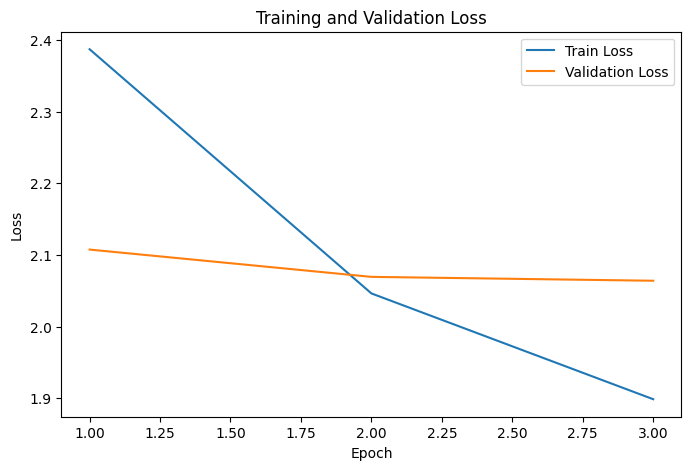

In [54]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Save Model

In [55]:
saving_format = f'{model_name.split('/')[-1]}-{dataset_name.split('/')[-1]}'

In [56]:
model.save_pretrained(f'/sft_model-{saving_format}')

In [57]:
tokenizer.save_pretrained(f'/sft_model-{saving_format}')

('/sft_model-gpt2-alpaca/tokenizer_config.json',
 '/sft_model-gpt2-alpaca/special_tokens_map.json',
 '/sft_model-gpt2-alpaca/vocab.json',
 '/sft_model-gpt2-alpaca/merges.txt',
 '/sft_model-gpt2-alpaca/added_tokens.json',
 '/sft_model-gpt2-alpaca/tokenizer.json')

## Evaluate

In [58]:
model.eval()
prompt = 'Instruction: Summarizing the following text. \nInput: Machine learning models require a lot of data and resources to perform well.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Summarizing the following text. 
Input: Machine learning models require a lot of data and resources to perform well.
Answer: Machine learning models are a type of data science model that uses deep learning techniques to classify and classify data.
Answer: Machine learning models are a type of data science model that uses deep learning techniques to classify and classify data.
Answer: Machine learning


In [59]:
model.eval()
prompt = 'Instruction: Explain. \nInput: What is machine learning.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Explain. 
Input: What is machine learning.
Answer: Machine learning is a type of artificial intelligence (AI) technology that is used to classify and classify data.
Answer: Machine learning is a type of artificial intelligence (AI) technology that is used to classify and classify data.
Answer: Machine learning


In [60]:
model.from_pretrained(f'/sft_model-{saving_format}')

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [65]:
import math

train_perplexity = [math.exp(l) for l in train_losses]
val_perplexity = [math.exp(l) for l in val_losses]

print(f"Epoch {epoch+1} Train Perplexity: {train_perplexity[-1]:.2f}")
print(f"Epoch {epoch+1} Validation Perplexity: {val_perplexity[-1]:.2f}")

Epoch 3 Train Perplexity: 6.68
Epoch 3 Validation Perplexity: 7.88


In [66]:
import numpy as np

avg_train_loss = np.mean(train_losses)
avg_val_loss = np.mean(val_losses)

print("Average Train Cross-Entropy Loss:", avg_train_loss)
print("Average Validation Cross-Entropy Loss:", avg_val_loss)

Average Train Cross-Entropy Loss: 2.1105744784673055
Average Validation Cross-Entropy Loss: 2.080185620466868
